#### ARTI 303 – Programming for AI (Assignment)
# Building a Basic Sentiment Analyzer with Python and TextBlob
____________________________________________________________________________________________


## Assessment Goal
The goal of this assessment is to design a simple text sentiment analyzer using Python and TextBlob.

## Assessment Weight
15% out of the total mark allocated for the course.

## Assessment Type
This is a **group** “practical” assignment, which means each group is expected to work on the assignment requirements on their own and submit their work based on their own efforts. Each group consists of **3-4 students**.
Assessment Specifications and Description
As the name suggests, sentiment analysis means to identify the view or emotion behind a situation. It basically means to analyze and find the emotion or intent behind a piece of text or speech or any mode of communication. In this Assessment, we will focus on the sentiment analysis of text data.
__________________________________________________________________________________________________

We, humans, communicate with each other in a variety of languages, and any language is just a mediator or a way in which we try to express ourselves. And, whatever we speak or write, has a sentiment associated with it. It might be positive or negative or it might be neutral as well.

Sentiment analysis has a wide range of applications across various industries. One of its most common uses is in the field of social media monitoring, where companies and brands leverage sentiment analysis to gain insights into customer opinions and reactions to their products or services. This information can help them make data-driven decisions, refine marketing strategies, and improve customer satisfaction. Sentiment analysis is also valuable in the financial sector, where it is used to analyze market sentiment and news sentiment to make more informed investment decisions. In the realm of customer support, sentiment analysis can be employed to gauge customer satisfaction and identify potential issues in real-time, allowing businesses to respond proactively. Moreover, sentiment analysis has applications in healthcare, politics, and even in the field of academic research to analyze public sentiment, assess public policies, and understand emotional trends within specific domains. Overall, sentiment analysis is a versatile tool that provides valuable insights into human emotions and opinions, making it applicable in a wide array of fields.

A simple sentiment analyzer can be built using TextBlob. TextBlob is a popular Python library for natural language processing (NLP) that simplifies the complexities of working with textual data. It offers a straightforward and user-friendly interface for various NLP tasks, including text classification, part-of-speech tagging, sentiment analysis, translation, and more. TextBlob is built on top of NLTK and Pattern, two other NLP libraries, making it easy to perform common NLP operations with just a few lines of code. It also provides a range of pre-trained models and datasets, making it accessible for users without extensive NLP expertise. Whether you need to analyze sentiment in customer reviews, categorize text documents, or perform basic language processing tasks, TextBlob is a versatile and efficient tool that simplifies NLP tasks in Python.

In this assessment, you are asked to develop an intelligent solution which classifies the sentiment in Amazon reviews. A potential user of the solution is a producer or a seller on Amazon who would like to analyze their product’s reviews. 

# Dataset Description
In this assessment, you will use a dataset of Amazon reviews of unlocked phone. PromptCloud extracted 400 thousand reviews of unlocked mobile phones sold on Amazon.com to find out insights with respect to reviews, ratings, price and their relationships. 

*You may access the dataset via this link https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones*

## Tools and libraries:
In this assessment, you will use the following tools and libraries:‎
- Python
- Pandas
- TextBlob

## Assessment Tasks

In [1]:
 
from textblob import TextBlob
import pandas as pd
import matplotlib.pyplot as plt


### Task1:

Write a Python function called `sentimentAnalyzer(text)`. This function takes a text (i.e review) and returns the sentiment as follow:

- Score < -0.2: returns **‘Negative’**
- Score between -0.2 and 0.2: returns **‘Neutral’**
- Score > 0.2: returns **‘Positive’**

The score is the polarity of text as determined by TextBlob. An example of creating a textblob object is:

`blob = TextBlob(text)`

*(Refer to TextBlob’s documentation to learn about determining polarity)*


In [8]:
class SentimentAnalyzer:
    def __init__(self, text):
        if text is None:
            text = ""
        self.text = str(text)
        self.blob = TextBlob(self.text)
        self.polarity = self.blob.sentiment.polarity

    def classify(self):
        if self.polarity < -0.2:
            return "Negative"
        elif self.polarity <= 0.2:
            return "Neutral"
        else:
            return "Positive"

### Task 2:
Verify that the function does classify the sentiment correctly by passing the following words to the function:


|   Word        | Polarity | Resulting Sentiment |
|:-------------:|:--------:|:-------------------:|
| happy         |   0.8    |      Positive       |
| exciting      |   0.3    |      Positive       |
| good          |   0.7    |      Positive       |
| rich          |  0.375   |      Positive       |
| smile         |   0.3    |      Positive       |
| sad           |  -0.5    |      Negative       |
| disappointed  | -0.75    |      Negative       |
| bad           | -0.699   |      Negative       |
| poor          |  -0.4    |      Negative       |
| anger         |  -0.7    |      Negative       |
| food          |   0      |      Neutral        |
| animal        |   0      |      Neutral        |

In [9]:
def sentimentAnalyzer(text):
    analyzer = SentimentAnalyzer(text)
    return analyzer.classify()

test_words = {
    "Positive": ["happy", "exciting", "good", "rich", "smile"],
    "Negative": ["sad", "disappointed", "bad", "poor", "anger"],
    "Neutral":  ["food", "animal"]
}

print("Testing sentimentAnalyzer(text):\n")

for expected_label, words in test_words.items():
    print(f"Expected sentiment: {expected_label}")
    for w in words:
        blob = TextBlob(w)
        polarity = blob.sentiment.polarity
        result = sentimentAnalyzer(w)
        print(f"  Word: {w:12s}  | Polarity: {polarity: .3f}  | sentimentAnalyzer: {result}")
    print()


Testing sentimentAnalyzer(text):

Expected sentiment: Positive
  Word: happy         | Polarity:  0.800  | sentimentAnalyzer: Positive
  Word: exciting      | Polarity:  0.300  | sentimentAnalyzer: Positive
  Word: good          | Polarity:  0.700  | sentimentAnalyzer: Positive
  Word: rich          | Polarity:  0.375  | sentimentAnalyzer: Positive
  Word: smile         | Polarity:  0.300  | sentimentAnalyzer: Positive

Expected sentiment: Negative
  Word: sad           | Polarity: -0.500  | sentimentAnalyzer: Negative
  Word: disappointed  | Polarity: -0.750  | sentimentAnalyzer: Negative
  Word: bad           | Polarity: -0.700  | sentimentAnalyzer: Negative
  Word: poor          | Polarity: -0.400  | sentimentAnalyzer: Negative
  Word: anger         | Polarity: -0.700  | sentimentAnalyzer: Negative

Expected sentiment: Neutral
  Word: food          | Polarity:  0.000  | sentimentAnalyzer: Neutral
  Word: animal        | Polarity:  0.000  | sentimentAnalyzer: Neutral



### Task 3:
Import the provided dataset into a Pandas DataFrame. Filter the data to only include one product of your choice. The product you select must have at least 1000 reviews. Then, describe the data related to your product. This includes:

- Product name
- Number of rows
- Number of columns
- Length of the shortest review, length of the longest review, and the average length of the review. ‎

In [10]:
# Load the full dataset
df = pd.read_csv("Amazon_Unlocked_Mobile.csv")

# Product name, Brand, Price, Rating, Review text, Review votes
df.columns = ['Product', 'Brand', 'Price', 'Rating', 'Review', 'Votes']

df.head()

product_df = df[df['Product'].str.startswith("Samsung Galaxy S4", na=False)].copy()
len(product_df)

# Create a review length column
product_df['Review_Length'] = product_df['Review'].astype(str).str.len()

product_name_examples = product_df['Product'].unique()
num_rows = len(product_df)
num_cols = product_df.shape[1]
min_len = product_df['Review_Length'].min()
max_len = product_df['Review_Length'].max()
avg_len = product_df['Review_Length'].mean()

print("=== Product information (Samsung Galaxy S4) ===")
print("Unique product names (sample):")
print(product_name_examples[:5])
print("\nNumber of rows (reviews):", num_rows)
print("Number of columns:", num_cols)
print("Shortest review length:", min_len)
print("Longest review length:", max_len)
print("Average review length:", avg_len)


=== Product information (Samsung Galaxy S4) ===
Unique product names (sample):
['Samsung Galaxy S4 - Unlocked (Black)'
 'Samsung Galaxy S4 16GB SPH-720T LTE Tri-Band Blue (Sprint)'
 'Samsung Galaxy S4 16GB Unlocked GSM Smartphone w/ 4G LTE also in USA - Black Mist'
 'Samsung Galaxy S4 16GB Unlocked GSM Smartphone w/ 4G LTE also in USA - Marble White'
 'Samsung Galaxy S4 Active Dive I9295 Unlocked International Version Blue']

Number of rows (reviews): 6056
Number of columns: 7
Shortest review length: 2
Longest review length: 8188
Average review length: 180.55003302509908


### Task 4:
Apply the function sentimentAnalyzer(text)to the text column in your dataframe. This should create a new column in the dataframe called (Sentiment) which includes the sentiment for each review. 

In [11]:
def sentimentAnalyzer(text):
    analyzer = SentimentAnalyzer(text)
    return analyzer.classify()

def compute_polarity(text):
    analyzer = SentimentAnalyzer(text)
    return analyzer.polarity

product_df['Polarity'] = product_df['Review'].apply(compute_polarity)
product_df['Sentiment'] = product_df['Review'].apply(sentimentAnalyzer)

product_df[['Product', 'Rating', 'Polarity', 'Sentiment', 'Review']].head()


,Product,Rating,Polarity,Sentiment,Review
341469,Samsung Galaxy S4 - Unlocked (Black),3,0.000000,Neutral,No
341470,Samsung Galaxy S4 - Unlocked (Black),5,0.500000,Positive,Its all ok
341471,Samsung Galaxy S4 - Unlocked (Black),5,0.000000,Neutral,excelent
341472,Samsung Galaxy S4 16GB SPH-720T LTE Tri-Band B...,5,0.760417,Positive,"Excellent device, Works fine!"
341473,Samsung Galaxy S4 16GB SPH-720T LTE Tri-Band B...,1,0.000000,Neutral,Is not what it said it was


### Task 5:
Using visualization and summative statistics (in pandas and matlibplot), describe the results of the sentiment analysis of your product and analyze the results. This should include: 

- Visualizations of the results. For example, a bar chart showing number of documents with positive, negative, and neutral sentiment. Include any visualization you think is helpful. 
- Examples of reviews with positive, negative, and neural sentiment along with their polarity.
- Insights on what your client (producer or seller) need to do to minimize the negative sentiment and improve their reputation and product.
- Examples of reviews where you think TextBlob might have assigned the wrong sentiment to the review. Explain why you think this happened. Note: You may use the rating column to assess TextBlob’s sentiment. 

Sentiment
Negative     296
Neutral     2381
Positive    3379
Name: count, dtype: int64


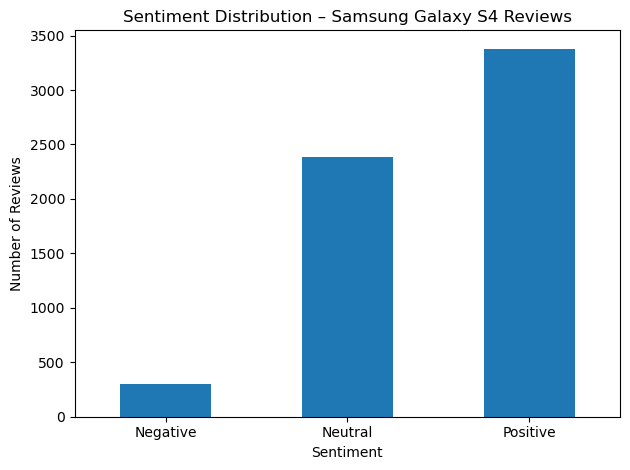

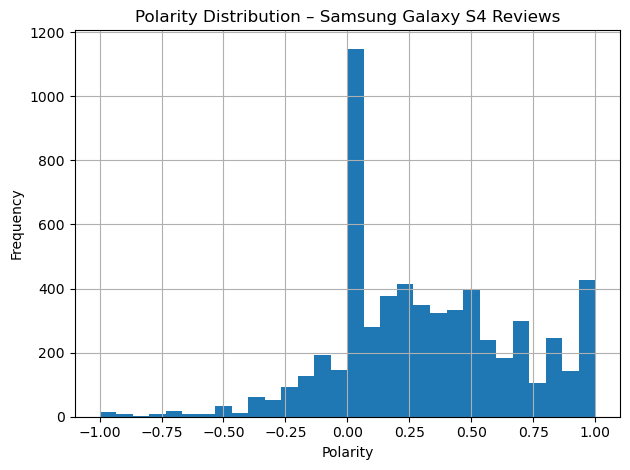


=== Positive reviews (examples) ===

Review #342251
Rating   : 5
Polarity : 0.800
Text     : Great phone.


Review #342074
Rating   : 5
Polarity : 0.800
Text     : Excellent phone received it within 3 days after I ordered it.veey nice phone.


Review #342349
Rating   : 5
Polarity : 0.800
Text     : Excellent phone received it within 3 days after I ordered it.veey nice phone.


=== Negative reviews (examples) ===

Review #347211
Rating   : 1
Polarity : -0.525
Text     : the phone is not good also the gps and internet connection bad if you are in the house the phone doesn't work


Review #344301
Rating   : 1
Polarity : -0.800
Text     : Yet another Amazon phone that is crap... Phone wasn't unlocked


Review #343068
Rating   : 1
Polarity : -0.337
Text     : Very very bad experience , my phone is not working well from beginning. Talked to Samsung Canada and USA . They said warranty is not covered in North America and this phone is having technical difficulties from beginning. Also IME num

,Rating,Polarity,Sentiment,Review
341495,2,0.250000,Positive,The phone looks good but had a few deffects bu...
341498,1,0.234375,Positive,I bought this phone months ago as a back up. N...
341538,1,0.221875,Positive,This phone is advertised as a Sprint phone. Do...
341556,2,0.250000,Positive,Ordered another phone better not be sprint pos...
341621,2,0.350000,Positive,"Cameras suck, and the phone just doesnt feel l..."
341696,2,0.350000,Positive,"Cameras suck, and the phone just doesnt feel l..."
341764,1,0.500000,Positive,Was defective...sent back....ended up getting ...
341772,1,0.288889,Positive,This phone cost me $225. It arrived on time. B...
341795,4,-0.750000,Negative,I had no adapter to charge it here in the USA....
341796,1,0.277778,Positive,Windows Phone is much better that either Andro...


In [12]:
#5.1 – Distribution of Sentiments (Bar Chart)
sentiment_counts = product_df['Sentiment'].value_counts().sort_index()

print(sentiment_counts)

plt.figure()
sentiment_counts.plot(kind='bar')
plt.title('Sentiment Distribution – Samsung Galaxy S4 Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#5.2 – Distribution of Polarity (Histogram)
plt.figure()
product_df['Polarity'].hist(bins=30)
plt.title('Polarity Distribution – Samsung Galaxy S4 Reviews')
plt.xlabel('Polarity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#5.3 – Show Example Reviews for Each Sentiment
def print_examples_for_sentiment(df, sentiment_label, n=3):
    print(f"\n=== {sentiment_label} reviews (examples) ===")
    subset = df[df['Sentiment'] == sentiment_label].sample(min(n, (df['Sentiment'] == sentiment_label).sum()), random_state=42)
    for i, row in subset.iterrows():
        print(f"\nReview #{i}")
        print(f"Rating   : {row['Rating']}")
        print(f"Polarity : {row['Polarity']:.3f}")
        print(f"Text     : {row['Review']}\n")

print_examples_for_sentiment(product_df, 'Positive', n=3)
print_examples_for_sentiment(product_df, 'Negative', n=3)
print_examples_for_sentiment(product_df, 'Neutral', n=3)

#5.4 – Find Reviews Where TextBlob Might Be “Wrong”

"""We compare sentiment vs rating:

Rating 1–2 but sentiment Positive

Rating 4–5 but sentiment Negative"""

mismatched_df = product_df[
    ((product_df['Rating'] <= 2) & (product_df['Sentiment'] == 'Positive')) |
    ((product_df['Rating'] >= 4) & (product_df['Sentiment'] == 'Negative'))
].copy()

print("Number of mismatched reviews:", len(mismatched_df))

mismatched_df[['Rating', 'Polarity', 'Sentiment', 'Review']].head(10)

### Task 6
Export the dataframe to a csv file. 

In [13]:
output_filename = "Samsung_Galaxy_S4_sentiment.csv"
product_df.to_csv(output_filename, index=False)
print(f"DataFrame exported successfully to: {output_filename}")

DataFrame exported successfully to: Samsung_Galaxy_S4_sentiment.csv


### Task 7
Write a technical report explaining the problem and outlining your results. Your ‎report should have the following:‎

- Title page
- Introduction
- Problem statement
- AI Solution
- Use case (the product you selected with the analysis results)‎
- Alignment between AI solution and client’s needs*‎
- Conclusion

* Your report must include a section which explains how the intelligent solution aligns with the client’s needs and requirements that are specified in the instructions (this document).


## Assessment Deadline:
The assignment is due: Thursday, December 4th , 2025.
## Assessment Deliverables:
You need to submit the complete notebook, your csv file (task 6), and assessment report.


@ 2025